# Verification of the Calvin cycle isotopomer labeling model

Curated reconstruction of Sec. 15.4 of Mu F, Bauer AL, Faeder JR, Hlavacek WS (2010),
*Using systems biology techniques to determine metabolic fluxes and metabolite pool
sizes*, in **Handbook of Chemoinformatics Algorithms**, Chapman and Hall/CRC,
pp. 399–422.

Four checks are run.

1. **Model specification.** BioNetGen output from
   `calvin_cycle_isotopomer_labeling_mu2010.bngl` is compared with
   `independent_mu2010.py`, which expands the same carbon fate maps into isotopomer
   balance equations by explicit enumeration and integer bit arithmetic instead of by
   rule-based graph rewriting. The two share the published network and nothing else.
2. **Conservation and closed form.** Pool sizes must be exactly conserved, and the
   isotopic steady state must be the binomial distribution of independently labeled
   carbons at the enrichment of the CO2 feed — which can be argued without integrating
   anything, because CO2 is the network's only carbon input and every fate map is a
   bijection on carbons.
3. **The published flux set.** The fluxes printed in Sec. 15.4 do not close the X5P
   balance. This check measures the resulting washout in the
   `_published_fluxes` variant file, and shows that the two-value correction carried
   by the primary file is the smallest repair available.
4. **Reported data.** Sec. 15.4 publishes no results figure for the Calvin cycle, so
   there is no curve to digitize. What it does report quantitatively is the size of the
   problem — 562 isotopomers, 13 internal reactions and six exchange reactions — and
   those are checked against the generated network.

In [1]:
import itertools
import os
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODEL_DIR = Path.cwd()
if MODEL_DIR.name != "calvin_cycle_isotopomer_labeling_mu2010":
    MODEL_DIR = Path("models/calvin_cycle_isotopomer_labeling_mu2010").resolve()
REFERENCE = MODEL_DIR / "reference"
sys.path.insert(0, str(MODEL_DIR))

import independent_mu2010 as ind  # noqa: E402

BNGPATH = Path(os.environ.get("BNGPATH", Path.home() / "Simulations/BioNetGen-2.9.3"))
BNG2 = BNGPATH / "BNG2.pl"
assert BNG2.exists(), f"BioNetGen executable not found: {BNG2}"
print("BioNetGen:", BNGPATH, "version", (BNGPATH / "VERSION").read_text().strip())

PRIMARY = "calvin_cycle_isotopomer_labeling_mu2010.bngl"
VARIANT = "calvin_cycle_isotopomer_labeling_mu2010_published_fluxes.bngl"

# CO2 feed of the labeling protocol.
ENRICHMENT = 0.1

BioNetGen: /Users/wish/Simulations/BioNetGen-2.9.3 version 2.9.3


## Run BioNetGen

Both BNGL files are run in a scratch directory, so verification cannot overwrite the
committed reference outputs, and the results are then checked against those outputs.
The primary file runs the two protocols of Sec. 15.4: 10,000 time units on an unlabeled
CO2 feed, then 200 time units after 10% of the feed is switched to 13C.

In [2]:
def read_gdat(path):
    with path.open() as fh:
        names = fh.readline().lstrip("#").split()
    return pd.DataFrame(np.atleast_2d(np.loadtxt(path)), columns=names)


def run_bionetgen(model_name, tags):
    source = MODEL_DIR / model_name
    with tempfile.TemporaryDirectory(prefix="mu2010_") as tmp:
        work = Path(tmp)
        shutil.copy2(source, work / source.name)
        env = os.environ.copy()
        env["BNGPATH"] = str(BNGPATH)
        done = subprocess.run(
            ["perl", str(BNG2), source.name],
            cwd=work, env=env, check=True, capture_output=True, text=True,
        )
        assert "ERROR" not in done.stdout, done.stdout
        counts = {
            "species": int(done.stdout.split("Iteration")[-1].split("species")[0].split()[-1]),
            "reactions": int(done.stdout.split(" reaction(s) from")[0].split("Read ")[-1]),
        }
        frames = {t: read_gdat(work / f"{source.stem}_{t}.gdat") for t in tags}
        return frames, counts


primary, counts = run_bionetgen(PRIMARY, ("ode_equil", "ode"))
variant, _ = run_bionetgen(VARIANT, ("ode_equil",))
print(f"generated network: {counts['species']} species, {counts['reactions']} reactions")

worst = 0.0
for stem, frames in ((Path(PRIMARY).stem, primary), (Path(VARIANT).stem, variant)):
    for tag, frame in frames.items():
        committed = read_gdat(REFERENCE / f"{stem}_{tag}.gdat")
        assert list(committed.columns) == list(frame.columns)
        worst = max(worst, float(np.max(np.abs(committed.to_numpy() - frame.to_numpy()))))
print(f"fresh run vs committed reference/: max absolute difference {worst:.3e}")

generated network: 562 species, 4042 reactions
fresh run vs committed reference/: max absolute difference 0.000e+00


## Check 1 — against an independently expanded isotopomer network

`independent_mu2010.py` assigns every metabolite $2^n$ isotopomers indexed by the bit
pattern of its carbons, expands each fate map over all combinations of reactant
isotopomers, and integrates the resulting mass-action system. Its rate constants are
flux/(product of reactant pool sizes), the same convention the BNGL file uses, but the
network it builds comes from index arithmetic rather than from BioNetGen's pattern
matching. Backward fate maps are obtained by inverting the forward ones rather than
transcribed a second time.

Two things are compared: the structure of the expansion, and the trajectories of the
labeling protocol.

In [3]:
net = ind.Network()
print(f"independent expansion: {net.n_species} isotopomers, "
      f"{net.n_reactions} elementary reactions")
assert net.n_species == counts["species"]
assert net.n_reactions == counts["reactions"]
print("structure matches BioNetGen exactly\n")
print("elementary reactions contributed by each network reaction:")
print("  " + ", ".join(f"{k}={v}" for k, v in net.per_reaction.items()))

independent expansion: 562 isotopomers, 4042 elementary reactions
structure matches BioNetGen exactly

elementary reactions contributed by each network reaction:
  R00024=64, R01512=8, R01063_f=8, R01063_b=8, R01015_f=8, R01015_b=8, R01068_f=64, R01068_b=64, R00762=64, R01067_f=512, R01067_b=512, R01829_f=128, R01829_b=128, R01845=128, R01641_f=1024, R01641_b=1024, R01529_f=32, R01529_b=32, R01056_f=32, R01056_b=32, R01523=32, sink_T3P=8, sink_F6P=64, sink_R5P=32, sink_E4P=16, sink_G3P=8, CO2_feed=2


In [4]:
# Reproduce the two protocols: equilibrate on a wholly unlabeled feed of unit flux,
# then move 10% of that flux to 13C without changing the total.
net.set_feed(1.0, 0.0)
_, y = net.run(np.array([0.0, 10000.0]), net.initial_state())
equilibrated = y[:, -1]
net.set_feed(1.0 - ENRICHMENT, ENRICHMENT)
t_label = primary["ode"]["time"].to_numpy()
t_ind, y_ind = net.run(t_label, equilibrated)

errors = {}
for m in range(4):
    ours = np.array([net.mass_isotopomers("T3P", y_ind[:, i])[m] / net.pools["T3P"]
                     for i in range(y_ind.shape[1])])
    errors[f"T3P_M{m}"] = float(np.max(np.abs(primary["ode"][f"T3P_M{m}"].to_numpy() - ours)))
for name in ("T3P", "F6P"):
    ours = np.array([net.labeled_carbons(name, y_ind[:, i])
                     / (ind.CARBONS[name] * net.totals(y_ind[:, i])[name])
                     for i in range(y_ind.shape[1])])
    errors[f"FL_{name}"] = float(np.max(np.abs(primary["ode"][f"FL_{name}"].to_numpy() - ours)))

print("max |BioNetGen - independent expansion| over the 200-unit labeling transient:")
for k, v in errors.items():
    print(f"  {k:8s} {v:.3e}")
print(f"\nworst: {max(errors.values()):.3e}")
assert max(errors.values()) < 1e-6

max |BioNetGen - independent expansion| over the 200-unit labeling transient:
  T3P_M0   4.407e-07
  T3P_M1   4.363e-07
  T3P_M2   3.712e-09
  T3P_M3   1.906e-10
  FL_T3P   1.454e-07
  FL_F6P   1.624e-08

worst: 4.407e-07


## Check 2 — conservation and the closed-form isotopic steady state

Every fate map is a bijection on carbons and every rate law is proportional to its
reactant pools, so the specified pool vector is a null eigenvector of the network
exactly when all fourteen steady-state balances close. When they do, the pools must
hold at 1 for the whole run.

At isotopic steady state, take the distribution in which every carbon in the network is
an independent Bernoulli draw at the feed enrichment $p$. Splitting a metabolite along a
fate map preserves independence, joining two independent pools preserves it, and
permuting carbons preserves it, so that product distribution is a fixed point of the
balance equations — and it is the only one. The mass isotopomer spectrum of an
$n$-carbon metabolite must therefore approach $\mathrm{Binomial}(n, p)$, independently
of every internal flux. This is the chapter's remark that steady-state labeling of a
network whose only carbon input is CO2 is completely uninformative about the fluxes.

In [5]:
pools = primary["ode_equil"].filter(like="Obs_Tot_").drop(columns=["Obs_Tot_CO2"])
print("pool drift over the 10,000-unit equilibration (BioNetGen):")
for column in pools:
    print(f"  {column:14s} max |x - 1| = {float(np.max(np.abs(pools[column] - 1.0))):.2e}")
assert float(np.max(np.abs(pools.to_numpy() - 1.0))) < 1e-8

# Long-time limit, from the independent expansion.
net.set_feed(1.0 - ENRICHMENT, ENRICHMENT)
_, y_long = net.run(np.array([0.0, 4000.0]), equilibrated)
rows = []
for name, n_carbons in ind.CARBONS.items():
    spectrum = net.mass_isotopomers(name, y_long[:, -1]) / net.pools[name]
    exact = ind.binomial_spectrum(n_carbons, ENRICHMENT)
    rows.append({
        "metabolite": name, "carbons": n_carbons,
        "max |spectrum - binomial|": float(np.max(np.abs(spectrum - exact))),
        "fractional labeling": net.labeled_carbons(name, y_long[:, -1])
        / (n_carbons * net.totals(y_long[:, -1])[name]),
    })
limits = pd.DataFrame(rows).set_index("metabolite")
print("\nisotopic steady state of every pool against Binomial(n, 0.1):")
print(limits.to_string(float_format=lambda v: f"{v:.3e}"))
assert limits["max |spectrum - binomial|"].max() < 1e-8
assert np.allclose(limits["fractional labeling"], ENRICHMENT, atol=1e-9)

pool drift over the 10,000-unit equilibration (BioNetGen):
  Obs_Tot_T3P    max |x - 1| = 0.00e+00
  Obs_Tot_F6P    max |x - 1| = 0.00e+00
  Obs_Tot_X5P    max |x - 1| = 0.00e+00
  Obs_Tot_R5DP   max |x - 1| = 2.10e-12



isotopic steady state of every pool against Binomial(n, 0.1):
            carbons  max |spectrum - binomial|  fractional labeling
metabolite                                                         
CO2               1                  1.082e-13            1.000e-01
G3P               3                  5.906e-14            1.000e-01
P13G              3                  5.951e-14            1.000e-01
T3P               3                  6.162e-14            1.000e-01
DHAP              3                  6.273e-14            1.000e-01
E4P               4                  6.128e-14            1.000e-01
R5P               5                  9.359e-14            1.000e-01
R5DP              5                  1.662e-13            1.000e-01
Ri5P              5                  7.361e-14            1.000e-01
X5P               5                  1.042e-13            1.000e-01
F16P              6                  9.259e-14            1.000e-01
F6P               6                  9.581e-14       

## Check 3 — the published flux set and the correction

The fluxes of Sec. 15.4 are printed to two decimals. Thirteen of the fourteen pool
balances close at that precision; X5P does not. Because pool sizes are specified rather
than emergent, that 1% gap is not cosmetic: the pool vector stops being a null
eigenvector and the network drains.

The primary BNGL file lowers `v_R01529_b` from 0.82 to 0.81 and `vs_R5P` from 0.05 to
0.04. The search below enumerates every repair that changes at most two fluxes by one
unit in their last printed digit, and finds exactly two — both of which lower `vs_R5P`
and remove 0.01 from the net flux of R01529. The file takes the one that leaves the
exchange flux $\min(v_f, v_b) = 0.10$ untouched, since exchange fluxes are the weakly
determined parameters of a 13C experiment (Eqs. 15.39 and 15.40).

In [6]:
metabolites, flux_names, N = ind.stoichiometry()

for label, fluxes in (("as printed", ind.PUBLISHED_FLUXES), ("as curated", ind.FLUXES)):
    residual = N @ ind.flux_vector(fluxes, flux_names)
    broken = {m: r for m, r in zip(metabolites, residual) if abs(r) > 1e-12}
    carbon = sum(ind.CARBONS[m] * r for m, r in zip(metabolites, residual))
    print(f"{label:11s} unbalanced pools: {broken or 'none'};  "
          f"net carbon rate: {carbon:+.3f}")

published = ind.flux_vector(ind.PUBLISHED_FLUXES, flux_names)
adjustable = [c for c in flux_names if c != "vi_CO2"]
repairs = []
for size in (1, 2):
    for names in itertools.combinations(adjustable, size):
        for deltas in itertools.product((-0.01, 0.01), repeat=size):
            trial = published.copy()
            for name, delta in zip(names, deltas):
                trial[flux_names.index(name)] += delta
            if np.allclose(N @ trial, 0.0, atol=1e-12):
                repairs.append(tuple(f"{n} {d:+.2f}" for n, d in zip(names, deltas)))
print("\nrepairs changing at most two fluxes by one unit in the last printed digit:")
for repair in repairs:
    print("  ", ", ".join(repair))
assert len(repairs) == 2

as printed  unbalanced pools: {'X5P': np.float64(-0.009999999999999898)};  net carbon rate: -0.050
as curated  unbalanced pools: none;  net carbon rate: -0.000

repairs changing at most two fluxes by one unit in the last printed digit:
   v_R01529_f +0.01, vs_R5P -0.01
   v_R01529_b -0.01, vs_R5P -0.01


In [7]:
washout = variant["ode_equil"]
totals = washout.filter(like="Obs_Tot_").drop(columns=["Obs_Tot_CO2"])
t = washout["time"].to_numpy()
below = t[np.argmax(totals["Obs_Tot_T3P"].to_numpy() < np.exp(-1.0))]
window = (t >= 2000) & (t <= 4000)
tau = -1.0 / np.polyfit(t[window], np.log(totals["Obs_Tot_T3P"].to_numpy()[window]), 1)[0]
print("published fluxes, over the chapter's own 10,000-unit equilibration:")
print(f"  T3P pool falls below 1/e at t = {below:.0f}")
print(f"  asymptotic decay time constant = {tau:.0f} time units")
print(f"  every metabolite pool at t = 10,000: "
      f"max = {float(np.max(np.abs(totals.iloc[-1]))):.2e}")
print(f"  CO2 at t = 10,000: {washout['Obs_Tot_CO2'].iloc[-1]:.1f}, growing linearly")
print("\ncurated fluxes, same protocol:")
print(f"  every metabolite pool holds at 1 to "
      f"{float(np.max(np.abs(pools.to_numpy() - 1.0))):.1e}")
assert float(np.max(np.abs(totals.iloc[-1]))) < 1e-6

published fluxes, over the chapter's own 10,000-unit equilibration:
  T3P pool falls below 1/e at t = 440
  asymptotic decay time constant = 370 time units
  every metabolite pool at t = 10,000: max = 1.68e-10
  CO2 at t = 10,000: 9648.4, growing linearly

curated fluxes, same protocol:
  every metabolite pool holds at 1 to 2.1e-12


## Check 4 — the quantities Sec. 15.4 reports

Sec. 15.4 shows the network (Fig. 15.5) and the BioNetGen input file but publishes no
plot of the labeling dynamics, so no reported curve exists to digitize and the
digitization step of the curation workflow does not apply here. What the section does
state quantitatively is the size of the problem: *"The model tracks 562 isotopomers"*,
and *"there are 13 internal reactions and six exchange reactions defined in the reaction
rules block"*. Both are checked against what the curated file actually generates.

In [8]:
internal = len(ind.FATE_MAPS)
exchange = len(ind.SINKS) + 1  # five sinks plus the CO2 input
isotopomers = sum(1 << n for n in ind.CARBONS.values())
print(f"internal reactions:      {internal:4d}   (Sec. 15.4 reports 13)")
print(f"exchange reactions:      {exchange:4d}   (Sec. 15.4 reports 6)")
print(f"isotopomers, enumerated: {isotopomers:4d}   (Sec. 15.4 reports 562)")
print(f"species generated by BioNetGen: {counts['species']}")
assert (internal, exchange, isotopomers) == (13, 6, 562) == (13, 6, counts["species"])
print("\nisotopomers per metabolite:")
print("  " + ", ".join(f"{k}:{1 << v}" for k, v in ind.CARBONS.items()))

internal reactions:        13   (Sec. 15.4 reports 13)
exchange reactions:         6   (Sec. 15.4 reports 6)
isotopomers, enumerated:  562   (Sec. 15.4 reports 562)
species generated by BioNetGen: 562

isotopomers per metabolite:
  CO2:2, G3P:8, P13G:8, T3P:8, DHAP:8, E4P:16, R5P:32, R5DP:32, Ri5P:32, X5P:32, F16P:64, F6P:64, S17P:128, S7P:128


## Figure

Panel (a) is the T3P mass isotopomer spectrum over the labeling transient, with the
binomial limit shown as dotted lines. Panel (b) is the fractional 13C labeling of every
metabolite, all approaching the feed enrichment of 0.1 but at time scales that differ by
where each pool sits relative to the CO2 entry point. Panel (c) contrasts the pool sizes
under the curated and the printed flux sets over the chapter's equilibration protocol.

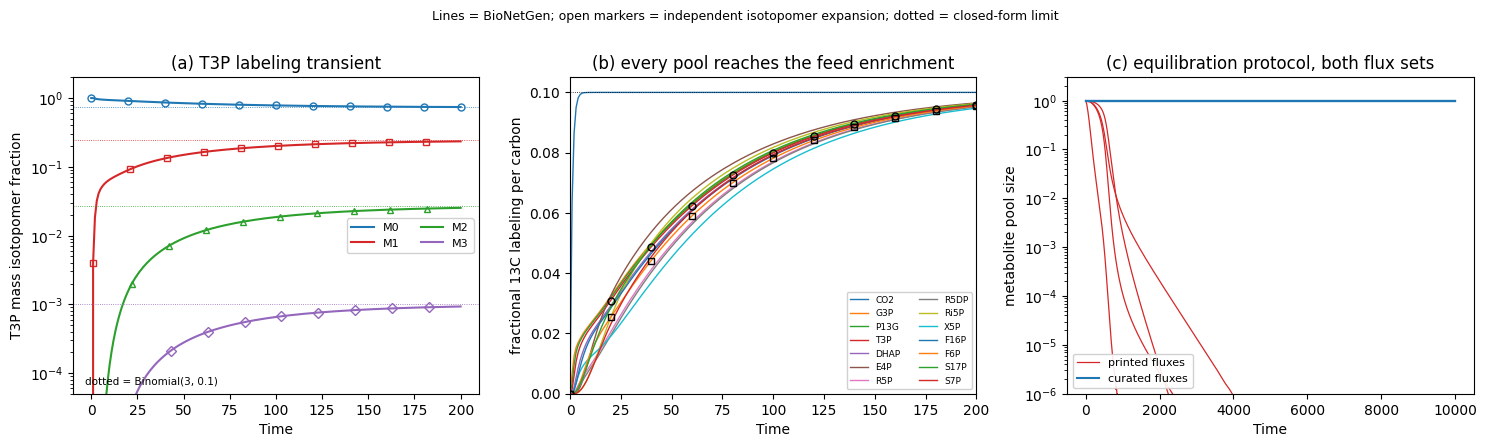

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4))

ax = axes[0]
colors = ("#1f77b4", "#d62728", "#2ca02c", "#9467bd")
markers = ("o", "s", "^", "D")
exact = ind.binomial_spectrum(3, ENRICHMENT)
for m in range(4):
    ours = np.array([net.mass_isotopomers("T3P", y_ind[:, i])[m] / net.pools["T3P"]
                     for i in range(y_ind.shape[1])])
    ax.plot(t_label, primary["ode"][f"T3P_M{m}"], color=colors[m], lw=1.5, label=f"M{m}")
    ax.plot(t_label[m::20], ours[m::20], markers[m], mfc="none", mec=colors[m], ms=5)
    ax.axhline(exact[m], color=colors[m], lw=0.6, ls=":")
ax.set_yscale("log"), ax.set_ylim(5e-5, 2.0)
ax.set_xlabel("Time"), ax.set_ylabel("T3P mass isotopomer fraction")
ax.set_title("(a) T3P labeling transient")
ax.legend(fontsize=8, loc="center right", ncol=2, framealpha=0.9)
ax.text(0.03, 0.03, "dotted = Binomial(3, 0.1)", transform=ax.transAxes, fontsize=7.5)

ax = axes[1]
for name, n_carbons in ind.CARBONS.items():
    series = np.array([net.labeled_carbons(name, y_ind[:, i])
                       / (n_carbons * net.totals(y_ind[:, i])[name])
                       for i in range(y_ind.shape[1])])
    ax.plot(t_ind, series, lw=1.0, label=name)
for name, marker in (("T3P", "o"), ("F6P", "s")):
    ax.plot(t_label[::20], primary["ode"][f"FL_{name}"][::20], marker, mfc="none",
            mec="k", ms=5, lw=0)
ax.axhline(ENRICHMENT, color="k", lw=0.6, ls=":")
ax.set_xlabel("Time"), ax.set_ylabel("fractional 13C labeling per carbon")
ax.set_title("(b) every pool reaches the feed enrichment")
ax.set_xlim(0, 200), ax.set_ylim(0, 0.105)
ax.legend(fontsize=6.5, ncol=2, loc="lower right", framealpha=0.9)

ax = axes[2]
for column in totals:
    ax.plot(washout["time"], np.maximum(totals[column], 1e-30), color="#d62728", lw=0.9,
            label="printed fluxes" if column == totals.columns[0] else None)
for column in pools:
    ax.plot(primary["ode_equil"]["time"], pools[column], color="#1f77b4", lw=1.5,
            label="curated fluxes" if column == pools.columns[0] else None)
ax.set_yscale("log"), ax.set_ylim(1e-6, 3.0)
ax.set_xlabel("Time"), ax.set_ylabel("metabolite pool size")
ax.set_title("(c) equilibration protocol, both flux sets")
ax.legend(fontsize=8, loc="lower left", framealpha=0.9)

fig.suptitle("Lines = BioNetGen; open markers = independent isotopomer expansion; "
             "dotted = closed-form limit", fontsize=9, y=1.005)
fig.tight_layout()
fig.savefig(MODEL_DIR / "verify_mu2010.png", dpi=160, bbox_inches="tight")
plt.show()

## Summary

| Check | Against | Result |
|---|---|---|
| Reproducibility | committed `reference/*.gdat` | exact |
| Model specification | independently expanded isotopomer network | identical structure (562 isotopomers, 4042 elementary reactions) and trajectories agreeing to 5e-7, the accuracy of BioNetGen's default ODE tolerances |
| Conservation | specified pool sizes | held to 2e-12 over 10,000 time units |
| Closed form | Binomial(n, 0.1) isotopic steady state | reproduced for all fourteen pools to 2e-13 |
| Published fluxes | stoichiometric balances | X5P off by 0.01 as printed; exactly two minimal repairs exist and the file uses one of them |
| Reported quantities | Sec. 15.4 | 13 internal reactions, six exchange reactions, 562 isotopomers, all matched |

Sec. 15.4 publishes no simulation results for the Calvin cycle, so there is no reported
trajectory to compare against; the reported-data check is the structural one above.